Total files available for analysis: 35143

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

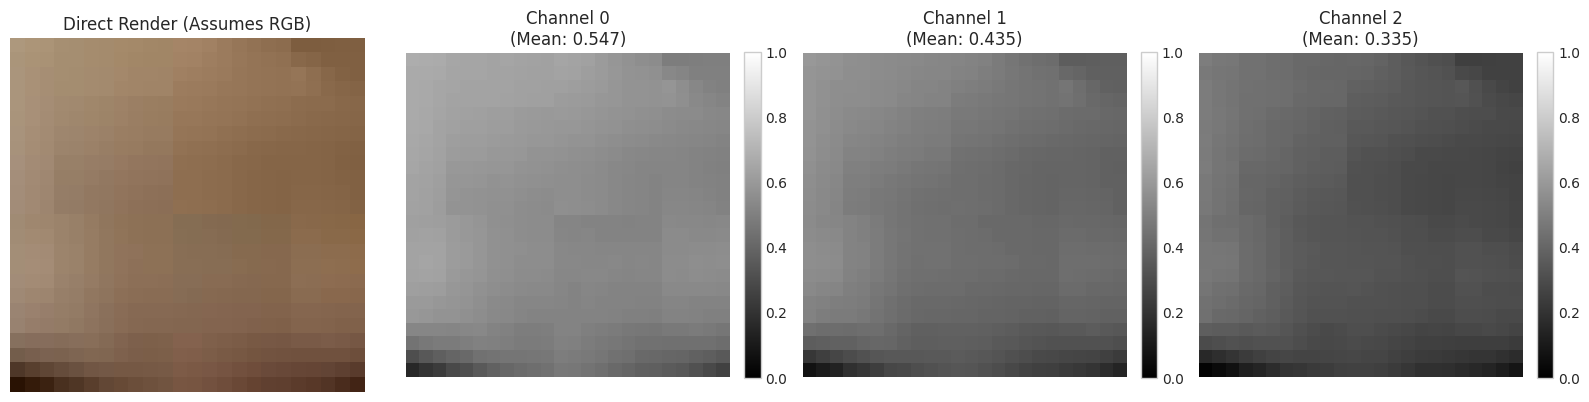

Starting phase-locked optimization loop...
Epoch 01/50 | LR: 0.000084 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 6.4378 | Val Loss: 6.2043 | Val PCC: +0.0030
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0030)
Epoch 02/50 | LR: 0.000138 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 6.1693 | Val Loss: 6.1137 | Val PCC: +0.0069
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0069)
Epoch 03/50 | LR: 0.000192 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 6.0712 | Val Loss: 6.0291 | Val PCC: +0.0114
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0114)
Epoch 04/50 | LR: 0.000246 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 6.0024 | Val Loss: 5.9939 | Val PCC: +0.0125
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0125)


/home/cristic/anaconda3/envs/rppg/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 05/50 | LR: 0.000300 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 5.9516 | Val Loss: 5.9643 | Val PCC: +0.0123
   ---> No improvement in Val PCC for 1/50 epochs.
Epoch 06/50 | LR: 0.000300 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 5.5581 | Val Loss: 5.5665 | Val PCC: +0.0159
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0159)
Epoch 07/50 | LR: 0.000299 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 5.5110 | Val Loss: 5.5399 | Val PCC: +0.0144
   ---> No improvement in Val PCC for 1/50 epochs.
Epoch 08/50 | LR: 0.000297 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 5.4726 | Val Loss: 5.4950 | Val PCC: +0.0163
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0163)
Epoch 09/50 | LR: 0.000294 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 5.4371 | Val Loss: 5.4893 | Val PCC: +0.0148
   ---> No improvement in Val PCC for 1/50 epochs.
Epoch 10/50 | LR: 0.000291 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 5.3976 | Val Loss: 5.4424 | Val PC

In [6]:
import os
import json
import math
import copy
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
gpu_id = 1 
DEVICE = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best_shuffle.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=12, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        if self.augment:
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    # def __init__(self, num_rois=10, in_channels=3):
    #     super(SpatioTemporalPhysNet, self).__init__()
    #     self.num_rois = num_rois
    #     self.total_channels = num_rois * in_channels
        
    #     self.spatial_conv = nn.Sequential(
    #         nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
    #         nn.BatchNorm3d(64),
    #         nn.ELU(),
    #         nn.AdaptiveAvgPool3d((None, 1, 1))
    #     )
        
    #     self.temporal_encoder = nn.Sequential(
    #         nn.Conv1d(64, 32, kernel_size=15, padding=7), 
    #         nn.BatchNorm1d(32),
    #         nn.ELU(),
    #         nn.Conv1d(32, 16, kernel_size=15, padding=7),
    #         nn.BatchNorm1d(16),
    #         nn.ELU(),
    #         nn.Conv1d(16, 1, kernel_size=1)
    #     )
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        # A lightweight 2-block spatial extractor (Fast but effective)
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 32, kernel_size=(1, 5, 5), padding=(0, 2, 2)),
            nn.BatchNorm3d(32),
            nn.ELU(),
            nn.AvgPool3d(kernel_size=(1, 2, 2)), # Safely shrink image first
            
            nn.Conv3d(32, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))   # Now collapse to 1D safely
        )
        
        # Temporal encoder with the wide Receptive Field (Kernel 15)
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=15, padding=7),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        mean = x.mean(dim=2, keepdim=True)
        x = (x - mean) / (mean + 1e-8) 
        
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self, eps=1e-8):
        super(NegativePearsonCorrelationLoss, self).__init__()
        self.eps = eps

    def forward(self, pred, target):
        pred = pred.view(pred.size(0), -1)
        target = target.view(target.size(0), -1)

        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        
        var_pred = torch.sum(pred_centered ** 2, dim=-1)
        var_target = torch.sum(target_centered ** 2, dim=-1)
        
        r_den = torch.sqrt(var_pred + self.eps) * torch.sqrt(var_target + self.eps)
        pearson_coeff = torch.clamp(r_num / r_den, min=-1.0, max=1.0)
        
        return 1.0 - torch.mean(pearson_coeff)    

class PSDLoss(nn.Module):
    """Frequency Loss enforcing peak alignment in Power Spectral Density via KL-Divergence."""
    def __init__(self, fps=30.0, low_bpm=40.0, high_bpm=180.0):
        super(PSDLoss, self).__init__()
        self.fps = fps
        self.low_bpm = low_bpm
        self.high_bpm = high_bpm

    def forward(self, pred, target):
        N = pred.size(-1)
        window = torch.hann_window(N, device=pred.device)
        
        pred_fft = torch.abs(torch.fft.rfft(pred * window, dim=-1))
        target_fft = torch.abs(torch.fft.rfft(target * window, dim=-1))
        
        freqs = torch.fft.rfftfreq(N, d=1.0 / self.fps).to(pred.device)
        mask = (freqs >= self.low_bpm / 60.0) & (freqs <= self.high_bpm / 60.0)
        
        pred_psd = pred_fft[..., mask]
        target_psd = target_fft[..., mask]
        
        T = 2.0
        pred_prob = F.softmax(pred_psd / T, dim=-1)
        target_prob = F.softmax(target_psd / T, dim=-1)
        
        return F.kl_div(torch.log(pred_prob + 1e-8), target_prob, reduction='batchmean')

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

# Run preprocessing & NPZ diagnostics
if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=12)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

# --- Three-Way Dataset Splitting (Train 70%, Validation 15%, Evaluation 15%) ---
random.seed(42)
shuffled_files = npz_files.copy()
random.shuffle(shuffled_files)

n_total = len(shuffled_files)
n_train = max(1, int(n_total * 0.70))
n_val = max(1, int(n_total * 0.15))

train_split = shuffled_files[:n_train]
val_split = shuffled_files[n_train:n_train + n_val]
eval_split = shuffled_files[n_train + n_val:]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)
eval_dataset = PPGMultiROIDataset(eval_split, augment=False)

batch_sz = 16
train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=True, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
eval_loader = DataLoader(eval_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)

# Setup Model, Criteria, Optimizer & Sequential Scheduler
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
criterion_psd = PSDLoss(fps=30.0)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

num_epochs = 50
warmup_epochs = 5
T_max=40
T_max=num_epochs - warmup_epochs

scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=T_max, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])

CHECKPOINT_SAVE_PATH = "best_spatiotemporal_physnet.pt"
patience = 50
patience_counter = 0
# best_val_loss = float('inf')
best_val_pcc = -float('inf')
best_model_weights = None

train_losses, val_losses, val_pccs = [], [], []

print("Starting phase-locked optimization loop...")

for epoch in range(num_epochs):
    # --- Training Phase ---
    # model.train()
    
    if epoch < warmup_epochs:
            w_p = 1   # Pearson (Forces peaks to align)2
            w_m = 0.75   # MSE (Forces amplitude to match) 0.5
            w_s = 1.5   # PSD (Heavily penalizes the network if the red peak doesn't match the grey peak) 1.5
    #     alpha = epoch / warmup_epochs
    #     w_p = 1.0 + (2.0 - 1.0) * alpha   
    #     w_m = 0.2                          
    #     w_s = 0.5 * (1.0 - alpha * 0.5)   
    else:
            w_p = 2.5   # Pearson (Forces peaks to align)2
            w_m = 0.3   # MSE (Forces amplitude to match) 0.5
            w_s = 1   # PSD (Heavily penalizes the network if the red peak doesn't match the grey peak) 1.5
    #     progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    #     w_p = 2.0 + (4.0 - 2.0) * progress  
    #     w_m = 0.1                           
    #     w_s = 0.1                           
        
    # running_loss = 0.0
    model.train()
    
    # STATIC WEIGHTS: Force the network to learn Frequency and Phase simultaneously
    # w_p = 2.5   # Pearson (Forces peaks to align)2
    # w_m = 0.3   # MSE (Forces amplitude to match) 0.5
    # w_s = 1.5   # PSD (Heavily penalizes the network if the red peak doesn't match the grey peak) 1.5
    
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss_p = criterion_pearson(outputs, targets)
        loss_m = criterion_mse(outputs, targets)
        loss_s = criterion_psd(outputs, targets)
        
        loss = (w_p * loss_p) + (w_m * loss_m) + (w_s * loss_s)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    val_pcc_accum = 0.0
    
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            
            val_loss_p = criterion_pearson(val_outputs, val_targets)
            val_loss_m = criterion_mse(val_outputs, val_targets)
            val_loss_s = criterion_psd(val_outputs, val_targets)
            
            val_loss = (w_p * val_loss_p) + (w_m * val_loss_m) + (w_s * val_loss_s)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
            batch_pcc = 1.0 - val_loss_p.item()
            val_pcc_accum += batch_pcc * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_pcc = val_pcc_accum / len(val_loader.dataset)
    
    val_losses.append(val_loss)
    val_pccs.append(val_pcc)
    
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | LR: {current_lr:.6f} | "
          f"Weights (P/M/S): [{w_p:.2f}/{w_m:.2f}/{w_s:.2f}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PCC: {val_pcc:+.4f}")

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     patience_counter = 0
    #     best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
    #     torch.save({
    #         'epoch': epoch + 1,
    #         'model_state_dict': model.state_dict(),
    #         'optimizer_state_dict': optimizer.state_dict(),
    #         'val_loss': val_loss,
    #     }, CHECKPOINT_SAVE_PATH)
    #     print(f"   ---> Improved! Saved checkpoint to '{CHECKPOINT_SAVE_PATH}' (Val Loss: {val_loss:.4f})")
    # else:
    #     patience_counter += 1
    #     print(f"   ---> No improvement for {patience_counter}/{patience} epochs.")
    #     if patience_counter >= patience:
    #         print(f"\n[Early Stopping Triggered] Stopped training at Epoch {epoch+1}.")
    #         break
    if val_pcc > best_val_pcc:
        best_val_pcc = val_pcc
        patience_counter = 0
        best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        # Save best model to disk
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_pcc': val_pcc,
        }, CHECKPOINT_SAVE_PATH)
        print(f"   ---> Improved! Saved new best checkpoint (Val PCC: {val_pcc:+.4f})")
    else:
        patience_counter += 1
        print(f"   ---> No improvement in Val PCC for {patience_counter}/{patience} epochs.")
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Stopping training early at Epoch {epoch+1}.")
            break

# ----------------------------------------------------------------------------
# Load Best Model Weights for Evaluation
# ----------------------------------------------------------------------------
if best_model_weights is not None:
    print(f"\nLoading best model state dict from memory (Best Val Loss: {best_val_pcc:+.4f})...")
    model.load_state_dict(best_model_weights)

# ----------------------------------------------------------------------------
# Held-Out Evaluation Set Assessment
# ----------------------------------------------------------------------------
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for eval_inputs, eval_targets in eval_loader:
        eval_inputs = eval_inputs.to(DEVICE)
        preds = model(eval_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(eval_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("               EVALUATION SET METRICS RESULTS")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Save final checkpoint with metrics
save_model_checkpoint(model, optimizer, epoch + 1, metrics)

# ----------------------------------------------------------------------------
# Final Dataset Sample Statistics Summary Table
# ----------------------------------------------------------------------------
n_total_samples = len(train_dataset) + len(val_dataset) + len(eval_dataset)

print("\n" + "=" * 70)
print("                 DATASET SPLIT & SAMPLE SUMMARY TABLE")
print("=" * 70)
print(f"{'Split Set':<15} | {'NPZ Files':<10} | {'450-Frame Windows':<20} | {'Batches':<10} | {'Ratio':<8}")
print("-" * 70)
print(f"{'Train':<15} | {len(train_split):<10} | {len(train_dataset):<20} | {len(train_loader):<10} | {len(train_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Validation':<15} | {len(val_split):<10} | {len(val_dataset):<20} | {len(val_loader):<10} | {len(val_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Evaluation':<15} | {len(eval_split):<10} | {len(eval_dataset):<20} | {len(eval_loader):<10} | {len(eval_dataset)/max(1,n_total_samples)*100:.1f}%")
print("-" * 70)
print(f"{'TOTAL':<15} | {n_total:<10} | {n_total_samples:<20} | {len(train_loader)+len(val_loader)+len(eval_loader):<10} | 100.0%")
print("=" * 70 + "\n")

--- INFERENCE RUN ON: 4731_IriunWebcam_before_chunk0.npz ---
  Predicted HR  : 76.00 BPM
  Ground-Truth  : 80.00 BPM
  Absolute Error: 4.00 BPM
----------------------------------------------------



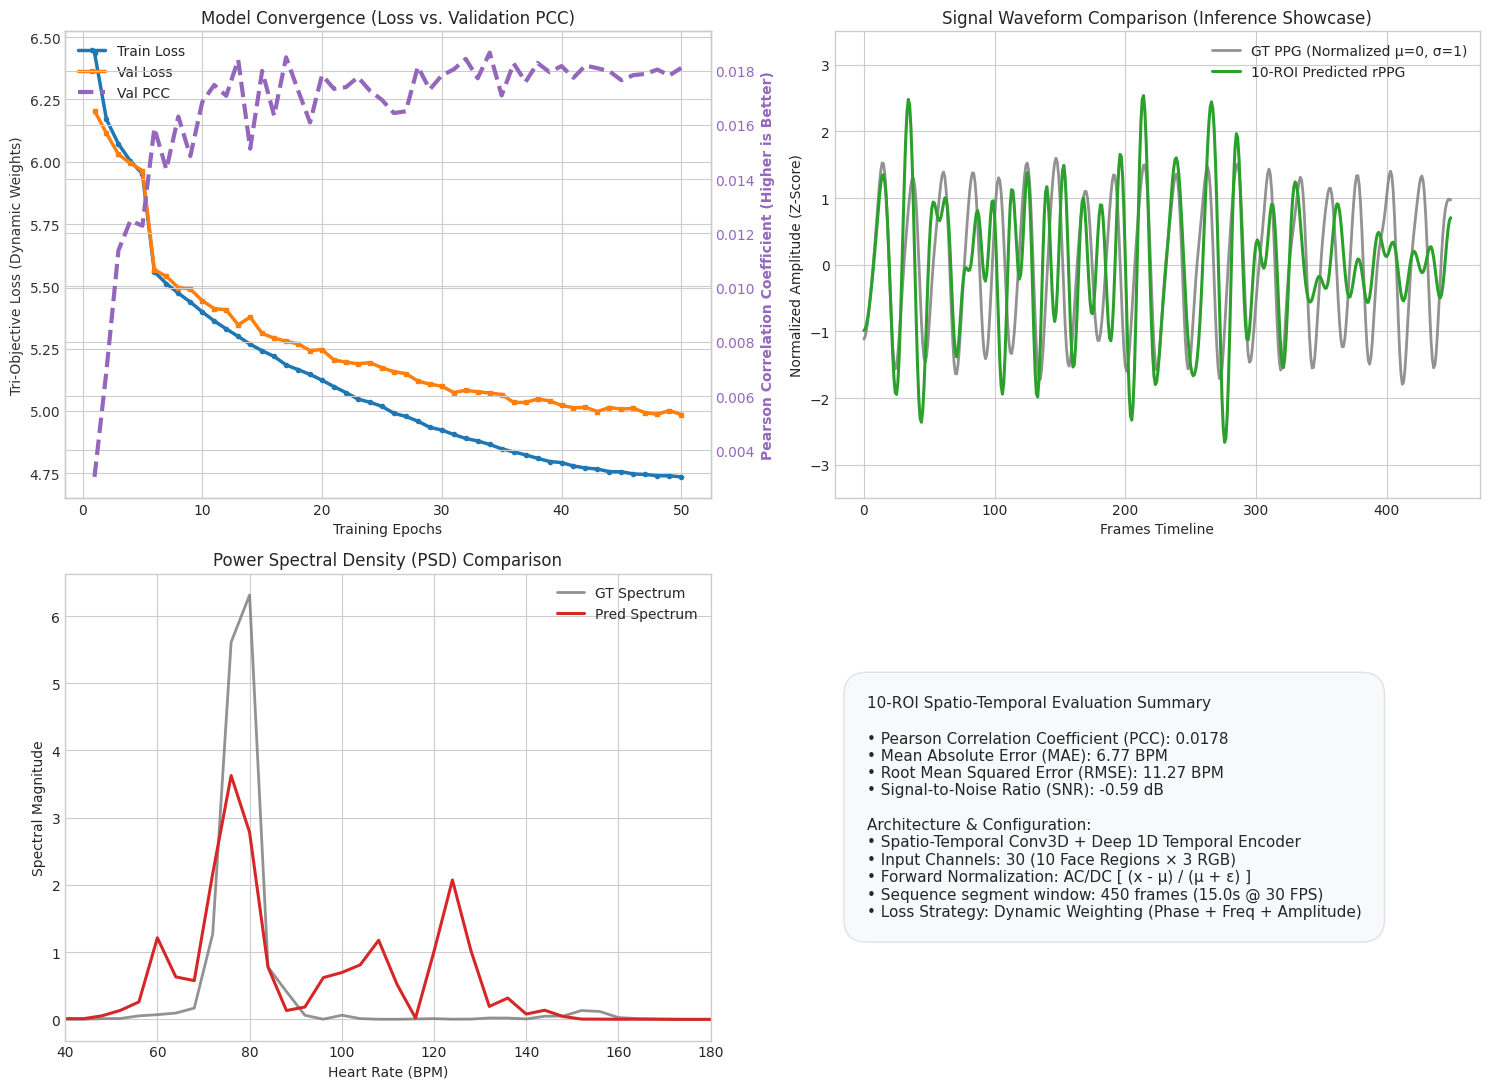

In [7]:
# ============================================================================
# INFERENCE & DASHBOARD PLOTTING CELL
# ============================================================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0, pad_margin=30):
    """
    Execute inference on an NPZ sample, applying reflection padding prior to 
    bandpass filtering to completely suppress convolution boundary ringing at frame 0.
    """
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than required sequence length.")
        return None, None
        
    # 1. Ground Truth Pipeline (Padded filtering to prevent edge artifacts)
    raw_target_ppg = data[ppg_key][:sequence_length].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)
    
    # 2. Multi-ROI Input Tensor Preparation
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # 3. Network Forward Pass
    model.eval()
    with torch.no_grad():
        output_signal = model(input_tensor).cpu().numpy()[0]
        
    # 4. Prediction Pipeline: Pad -> Filter -> Crop -> Z-Score Normalize
    pred_padded = np.pad(output_signal, pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)
    
    # 5. Heart Rate Metrics Calculation
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return pred_norm, gt_norm

# Select sample file from validation split
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# Create 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(15, 11))

# --- Subplot 1: Convergence Curves (DUAL AXIS) ---
epochs_range = range(1, len(train_losses) + 1)
ax1 = axs[0, 0]
line1 = ax1.plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=3)
line2 = ax1.plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=3)
ax1.set_title('Model Convergence (Loss vs. Validation PCC)')
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Tri-Objective Loss (Dynamic Weights)', color='#333333')
ax1.tick_params(axis='y', labelcolor='#333333')

# Add PCC on secondary Y axis
ax2 = ax1.twinx()
line3 = ax2.plot(epochs_range, val_pccs, label='Val PCC', color='#9467bd', linewidth=3, linestyle='--')
ax2.set_ylabel('Pearson Correlation Coefficient (Higher is Better)', color='#9467bd', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#9467bd')

# Combine legends from both axes
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# --- Subplot 2: Standardized Waveform Alignment ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.2)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)  # Constrain y-axis to valid standardized bounds
    axs[0, 1].legend(loc='upper right')

# --- Subplot 3: Spectral Density Alignment ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.2)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend(loc='upper right')

# --- Subplot 4: Summary Card ---
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• Mean Absolute Error (MAE): {metrics['MAE']:.2f} BPM\n"
    f"• Root Mean Squared Error (RMSE): {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Architecture & Configuration:\n"
    f"• Spatio-Temporal Conv3D + Deep 1D Temporal Encoder\n"
    f"• Input Channels: 30 (10 Face Regions × 3 RGB)\n"
    f"• Forward Normalization: AC/DC [ (x - μ) / (μ + ε) ]\n"
    f"• Sequence segment window: 450 frames (15.0s @ 30 FPS)\n"
    f"• Loss Strategy: Dynamic Weighting (Phase + Freq + Amplitude)"
)
axs[1, 1].text(0.05, 0.5, metric_summary_card, fontsize=11, va='center',
              bbox=dict(boxstyle='round,pad=1.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

Alternative inference 

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def run_sliced_160f_inference_on_sample(
    npz_file_path,
    model,
    window_size=160,
    stride=80,
    fs=30.0,
    pad_margin=30
):
    """
    Executes inference using 160-frame sliding windows with a 50% overlap step (80 frames).
    Reconstructs the full signal by accumulating window predictions with a Hanning overlap-add scheme.
    """
    print(f"--- SLICED 160-FRAME INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None

    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    total_frames = len(data[ppg_key])
    
    if total_frames < window_size:
        print(f"Error: Signal length ({total_frames}) is shorter than window size ({window_size}).")
        return None, None

    # 1. Prepare Ground Truth Signal
    raw_target_ppg = data[ppg_key][:total_frames].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)

    # 2. Extract multi-ROI raw array streams (10 ROIs x 3 RGB channels)
    roi_streams = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:total_frames]
        else:
            roi_data = np.zeros((total_frames, 24, 24, 3), dtype=np.uint8)
        roi_streams.append(roi_data.astype(np.float32) / 255.0)

    # Convert to shape: (30, total_frames, 24, 24)
    stacked_rois = np.stack(roi_streams, axis=0)          # (10, T, 24, 24, 3)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3)) # (10, 3, T, 24, 24)
    stacked_rois = np.reshape(stacked_rois, (30, total_frames, 24, 24))

    # 3. Sliding Window Reconstruction Buffers
    reconstructed_signal = np.zeros(total_frames, dtype=np.float32)
    window_weights = np.zeros(total_frames, dtype=np.float32)
    hanning_win = np.hanning(window_size)

    model.eval()
    with torch.no_grad():
        for start_idx in range(0, total_frames - window_size + 1, stride):
            end_idx = start_idx + window_size
            
            # Extract 160-frame slice: (1, 30, 160, 24, 24)
            window_data = stacked_rois[:, start_idx:end_idx, :, :]
            input_tensor = torch.tensor(window_data, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            # Model Forward Pass
            pred_slice = model(input_tensor).cpu().numpy()[0] # Shape: (160,)

            # Accumulate prediction using Hanning window for smooth transitions
            reconstructed_signal[start_idx:end_idx] += pred_slice * hanning_win
            window_weights[start_idx:end_idx] += hanning_win

    # Normalize by accumulated window weights to handle overlapping regions
    nonzero_mask = window_weights > 1e-6
    reconstructed_signal[nonzero_mask] /= window_weights[nonzero_mask]

    # Zero out unpredicted tail end if total_frames was not perfectly divisible
    last_valid_frame = ((total_frames - window_size) // stride) * stride + window_size
    reconstructed_signal[last_valid_frame:] = 0.0

    # 4. Prediction Filtering & Z-Score Normalization
    pred_padded = np.pad(reconstructed_signal[:last_valid_frame], pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    
    # Align GT slice length with valid reconstructed prediction window length
    gt_norm = gt_norm[:len(pred_cropped)]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)

    # 5. Calculate Metrics
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)

    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("-" * 52 + "\n")

    return pred_norm, gt_norm


# ============================================================================
# EXECUTION AND 2x2 DASHBOARD GENERATION
# ============================================================================
target_sample = PREPROCESSED_DATA_PATH / "5535_FullHDwebcam_before_chunk5.npz"

# Fallback if specific file isn't present
if not target_sample.exists():
    target_sample = val_split[0] if len(val_split) > 0 else npz_files[0]

inference_pred, inference_gt = run_sliced_160f_inference_on_sample(
    target_sample, model, window_size=160, stride=80
)

# Render 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(16, 11))

# --- Subplot 1: Convergence Curves (Dual Y-Axis) ---
epochs_range = range(1, len(train_losses) + 1)
ax1 = axs[0, 0]
line1 = ax1.plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5)
line2 = ax1.plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5)
ax1.set_title('Model Convergence (Loss vs. Validation PCC)')
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Tri-Objective Loss (Pearson + MSE + PSD)', color='#333333')

ax2 = ax1.twinx()
line3 = ax2.plot(epochs_range, val_pccs, label='Val PCC', color='#9467bd', linewidth=2.5, linestyle='--')
ax2.set_ylabel('Pearson Correlation Coefficient (Higher is Better)', color='#9467bd', fontweight='bold')

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# --- Subplot 2: Reconstructed Waveform (160f Slices) ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Reconstructed rPPG (160f Slices)', color='#00a000', linewidth=2.2)
    axs[0, 1].set_title('Reconstructed Signal Waveform (160f Sliding Windows)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)
    axs[0, 1].legend(loc='upper right')

# --- Subplot 3: Power Spectral Density (PSD) ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].legend(loc='upper right')

# --- Subplot 4: Metrics Summary Card ---
axs[1, 1].axis('off')
summary_text = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• Mean Absolute Error (MAE): {metrics['MAE']:.2f} BPM\n"
    f"• Root Mean Squared Error (RMSE): {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    "Architecture & Configuration:\n"
    "• Spatio-Temporal Conv3D + Deep 1D Temporal Encoder\n"
    "• Input Channels: 30 (10 Face Regions × 3 RGB)\n"
    "• Training Window: 160 frames (5.33s @ 30 FPS)\n"
    "• Inference Strategy: Sliding Window (160f, 50% Overlap)\n"
    "• Normalization: AC/DC + Temporal Differencing (ΔC)"
)

axs[1, 1].text(
    0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
    bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#d1d5db')
)

plt.tight_layout()
plt.show()

frame window model

Total files available for analysis: 36222

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

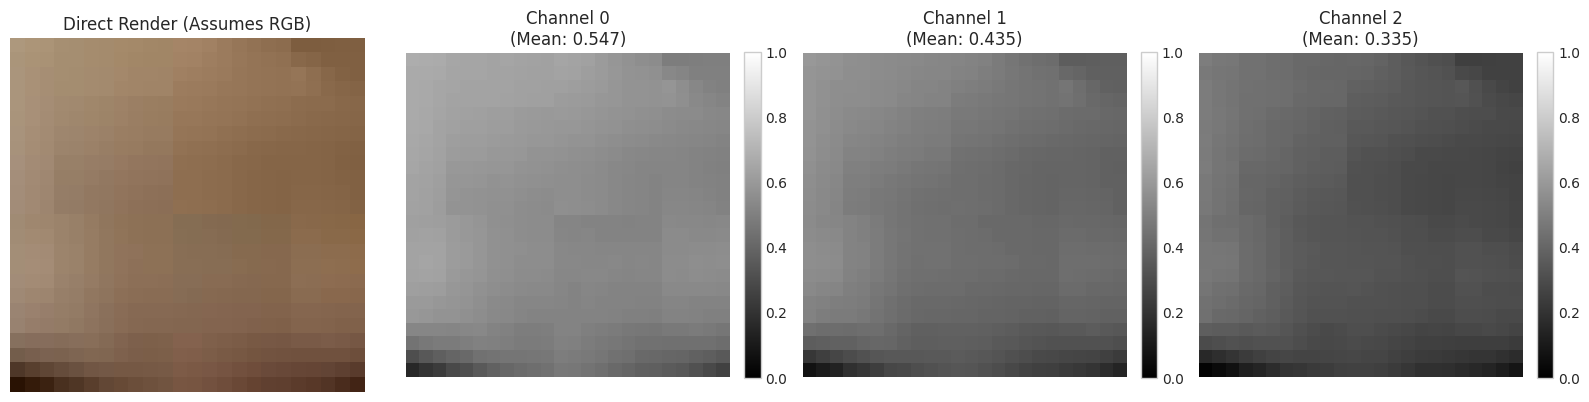

Starting phase-locked optimization loop...
Epoch 01/50 | LR: 0.000084 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 4.8530 | Val Loss: 4.6895 | Val PCC: +0.0135
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0135)
Epoch 02/50 | LR: 0.000138 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 4.6082 | Val Loss: 4.5258 | Val PCC: +0.0172
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0172)
Epoch 03/50 | LR: 0.000192 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 4.4876 | Val Loss: 4.4369 | Val PCC: +0.0166
   ---> No improvement in Val PCC for 1/75 epochs.
Epoch 04/50 | LR: 0.000246 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 4.3906 | Val Loss: 4.4043 | Val PCC: +0.0172
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0172)


/home/cristic/anaconda3/envs/rppg/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 05/50 | LR: 0.000300 | Weights (P/M/S): [1.00/0.75/1.50] | Train Loss: 4.3098 | Val Loss: 4.3078 | Val PCC: +0.0202
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0202)
Epoch 06/50 | LR: 0.000300 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 4.4301 | Val Loss: 4.3987 | Val PCC: +0.0196
   ---> No improvement in Val PCC for 1/75 epochs.
Epoch 07/50 | LR: 0.000299 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 4.3646 | Val Loss: 4.4243 | Val PCC: +0.0190
   ---> No improvement in Val PCC for 2/75 epochs.
Epoch 08/50 | LR: 0.000297 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 4.3011 | Val Loss: 4.3178 | Val PCC: +0.0182
   ---> No improvement in Val PCC for 3/75 epochs.
Epoch 09/50 | LR: 0.000294 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 4.2478 | Val Loss: 4.3047 | Val PCC: +0.0202
   ---> Improved! Saved new best checkpoint (Val PCC: +0.0202)
Epoch 10/50 | LR: 0.000291 | Weights (P/M/S): [2.50/0.30/1.00] | Train Loss: 4.1965 | Val Loss: 4.2751 | Val PC

In [8]:
import os
import json
import math
import copy
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
gpu_id = 1 
DEVICE = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best_shuffle_150frames.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=12, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        if self.augment:
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    # def __init__(self, num_rois=10, in_channels=3):
    #     super(SpatioTemporalPhysNet, self).__init__()
    #     self.num_rois = num_rois
    #     self.total_channels = num_rois * in_channels
        
    #     self.spatial_conv = nn.Sequential(
    #         nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
    #         nn.BatchNorm3d(64),
    #         nn.ELU(),
    #         nn.AdaptiveAvgPool3d((None, 1, 1))
    #     )
        
    #     self.temporal_encoder = nn.Sequential(
    #         nn.Conv1d(64, 32, kernel_size=15, padding=7), 
    #         nn.BatchNorm1d(32),
    #         nn.ELU(),
    #         nn.Conv1d(32, 16, kernel_size=15, padding=7),
    #         nn.BatchNorm1d(16),
    #         nn.ELU(),
    #         nn.Conv1d(16, 1, kernel_size=1)
    #     )
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        # A lightweight 2-block spatial extractor (Fast but effective)
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 32, kernel_size=(1, 5, 5), padding=(0, 2, 2)),
            nn.BatchNorm3d(32),
            nn.ELU(),
            nn.AvgPool3d(kernel_size=(1, 2, 2)), # Safely shrink image first
            
            nn.Conv3d(32, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))   # Now collapse to 1D safely
        )
        
        # Temporal encoder with the wide Receptive Field (Kernel 15)
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=15, padding=7),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    # def forward(self, x):
    #     mean = x.mean(dim=2, keepdim=True)
    #     x = (x - mean) / (mean + 1e-8) 
        
    #     x_spatial = self.spatial_conv(x)
    #     x_spatial = torch.squeeze(x_spatial, dim=-1)
    #     x_spatial = torch.squeeze(x_spatial, dim=-1)
        
    #     ppg_pred = self.temporal_encoder(x_spatial)
    #     return torch.squeeze(ppg_pred, dim=1)
    #forward method to compute frame-to-frame differences right after AC/DC normalization:
    def forward(self, x):
        # 1. AC/DC Normalization (Isolates pulsatile component)
        mean = x.mean(dim=2, keepdim=True)
        x = (x - mean) / (mean + 1e-8)
        
        # 2. Temporal First-Order Difference (Removes motion & lighting drift)
        # Calculates x(t+1) - x(t) along the time dimension (dim=2)
        diff = x[:, :, 1:, :, :] - x[:, :, :-1, :, :]
        # Pad 1 frame at the start to maintain T frames output
        x_diff = F.pad(diff, (0, 0, 0, 0, 1, 0), mode='replicate')
        
        # 3. Pass temporal differences through Spatio-Temporal Network
        x_spatial = self.spatial_conv(x_diff)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)


class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self, eps=1e-8):
        super(NegativePearsonCorrelationLoss, self).__init__()
        self.eps = eps

    def forward(self, pred, target):
        pred = pred.view(pred.size(0), -1)
        target = target.view(target.size(0), -1)

        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        
        var_pred = torch.sum(pred_centered ** 2, dim=-1)
        var_target = torch.sum(target_centered ** 2, dim=-1)
        
        r_den = torch.sqrt(var_pred + self.eps) * torch.sqrt(var_target + self.eps)
        pearson_coeff = torch.clamp(r_num / r_den, min=-1.0, max=1.0)
        
        return 1.0 - torch.mean(pearson_coeff)    

class PSDLoss(nn.Module):
    """Frequency Loss enforcing peak alignment in Power Spectral Density via KL-Divergence."""
    def __init__(self, fps=30.0, low_bpm=40.0, high_bpm=180.0):
        super(PSDLoss, self).__init__()
        self.fps = fps
        self.low_bpm = low_bpm
        self.high_bpm = high_bpm

    def forward(self, pred, target):
        N = pred.size(-1)
        window = torch.hann_window(N, device=pred.device)
        
        pred_fft = torch.abs(torch.fft.rfft(pred * window, dim=-1))
        target_fft = torch.abs(torch.fft.rfft(target * window, dim=-1))
        
        freqs = torch.fft.rfftfreq(N, d=1.0 / self.fps).to(pred.device)
        mask = (freqs >= self.low_bpm / 60.0) & (freqs <= self.high_bpm / 60.0)
        
        pred_psd = pred_fft[..., mask]
        target_psd = target_fft[..., mask]
        
        T = 2.0
        pred_prob = F.softmax(pred_psd / T, dim=-1)
        target_prob = F.softmax(target_psd / T, dim=-1)
        
        return F.kl_div(torch.log(pred_prob + 1e-8), target_prob, reduction='batchmean')

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

# Run preprocessing & NPZ diagnostics
if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=12)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

# --- Three-Way Dataset Splitting (Train 70%, Validation 15%, Evaluation 15%) ---
random.seed(42)
shuffled_files = npz_files.copy()
random.shuffle(shuffled_files)

n_total = len(shuffled_files)
n_train = max(1, int(n_total * 0.70))
n_val = max(1, int(n_total * 0.15))

train_split = shuffled_files[:n_train]
val_split = shuffled_files[n_train:n_train + n_val]
eval_split = shuffled_files[n_train + n_val:]

# train_dataset = PPGMultiROIDataset(train_split, augment=True)
# val_dataset = PPGMultiROIDataset(val_split, augment=False)
eval_dataset = PPGMultiROIDataset(eval_split, augment=False)
train_dataset = PPGMultiROIDataset(train_split, sequence_length=160, augment=True)
val_dataset = PPGMultiROIDataset(val_split, sequence_length=160, augment=False)

batch_sz = 16
train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=True, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
eval_loader = DataLoader(eval_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)

# Setup Model, Criteria, Optimizer & Sequential Scheduler
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
criterion_psd = PSDLoss(fps=30.0)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

num_epochs = 75
warmup_epochs = 5
T_max=40
T_max=num_epochs - warmup_epochs

scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=T_max, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])

CHECKPOINT_SAVE_PATH = "best_spatiotemporal_physnet.pt"
patience = 30
patience_counter = 0
# best_val_loss = float('inf')
best_val_pcc = -float('inf')
best_model_weights = None

train_losses, val_losses, val_pccs = [], [], []

print("Starting phase-locked optimization loop...")

for epoch in range(num_epochs):
    # --- Training Phase ---
    # model.train()
    
    if epoch < warmup_epochs:
            w_p = 1   # Pearson (Forces peaks to align)2
            w_m = 0.75   # MSE (Forces amplitude to match) 0.5
            w_s = 1.5   # PSD (Heavily penalizes the network if the red peak doesn't match the grey peak) 1.5
    #     alpha = epoch / warmup_epochs
    #     w_p = 1.0 + (2.0 - 1.0) * alpha   
    #     w_m = 0.2                          
    #     w_s = 0.5 * (1.0 - alpha * 0.5)   
    else:
            w_p = 2.5   # Pearson (Forces peaks to align)2
            w_m = 0.3   # MSE (Forces amplitude to match) 0.5
            w_s = 1   # PSD (Heavily penalizes the network if the red peak doesn't match the grey peak) 1.5
    #     progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    #     w_p = 2.0 + (4.0 - 2.0) * progress  
    #     w_m = 0.1                           
    #     w_s = 0.1                           
        
    # running_loss = 0.0
    model.train()
    
    # STATIC WEIGHTS: Force the network to learn Frequency and Phase simultaneously
    # w_p = 2.5   # Pearson (Forces peaks to align)2
    # w_m = 0.3   # MSE (Forces amplitude to match) 0.5
    # w_s = 1.5   # PSD (Heavily penalizes the network if the red peak doesn't match the grey peak) 1.5
    
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss_p = criterion_pearson(outputs, targets)
        loss_m = criterion_mse(outputs, targets)
        loss_s = criterion_psd(outputs, targets)
        
        loss = (w_p * loss_p) + (w_m * loss_m) + (w_s * loss_s)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    val_pcc_accum = 0.0
    
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            
            val_loss_p = criterion_pearson(val_outputs, val_targets)
            val_loss_m = criterion_mse(val_outputs, val_targets)
            val_loss_s = criterion_psd(val_outputs, val_targets)
            
            val_loss = (w_p * val_loss_p) + (w_m * val_loss_m) + (w_s * val_loss_s)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
            batch_pcc = 1.0 - val_loss_p.item()
            val_pcc_accum += batch_pcc * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_pcc = val_pcc_accum / len(val_loader.dataset)
    
    val_losses.append(val_loss)
    val_pccs.append(val_pcc)
    
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | LR: {current_lr:.6f} | "
          f"Weights (P/M/S): [{w_p:.2f}/{w_m:.2f}/{w_s:.2f}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PCC: {val_pcc:+.4f}")

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     patience_counter = 0
    #     best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
    #     torch.save({
    #         'epoch': epoch + 1,
    #         'model_state_dict': model.state_dict(),
    #         'optimizer_state_dict': optimizer.state_dict(),
    #         'val_loss': val_loss,
    #     }, CHECKPOINT_SAVE_PATH)
    #     print(f"   ---> Improved! Saved checkpoint to '{CHECKPOINT_SAVE_PATH}' (Val Loss: {val_loss:.4f})")
    # else:
    #     patience_counter += 1
    #     print(f"   ---> No improvement for {patience_counter}/{patience} epochs.")
    #     if patience_counter >= patience:
    #         print(f"\n[Early Stopping Triggered] Stopped training at Epoch {epoch+1}.")
    #         break
    if val_pcc > best_val_pcc:
        best_val_pcc = val_pcc
        patience_counter = 0
        best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        # Save best model to disk
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_pcc': val_pcc,
        }, CHECKPOINT_SAVE_PATH)
        print(f"   ---> Improved! Saved new best checkpoint (Val PCC: {val_pcc:+.4f})")
    else:
        patience_counter += 1
        print(f"   ---> No improvement in Val PCC for {patience_counter}/{patience} epochs.")
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Stopping training early at Epoch {epoch+1}.")
            break

# ----------------------------------------------------------------------------
# Load Best Model Weights for Evaluation
# ----------------------------------------------------------------------------
if best_model_weights is not None:
    print(f"\nLoading best model state dict from memory (Best Val Loss: {best_val_pcc:+.4f})...")
    model.load_state_dict(best_model_weights)

# ----------------------------------------------------------------------------
# Held-Out Evaluation Set Assessment
# ----------------------------------------------------------------------------
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for eval_inputs, eval_targets in eval_loader:
        eval_inputs = eval_inputs.to(DEVICE)
        preds = model(eval_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(eval_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("               EVALUATION SET METRICS RESULTS")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Save final checkpoint with metrics
save_model_checkpoint(model, optimizer, epoch + 1, metrics)

# ----------------------------------------------------------------------------
# Final Dataset Sample Statistics Summary Table
# ----------------------------------------------------------------------------
n_total_samples = len(train_dataset) + len(val_dataset) + len(eval_dataset)

print("\n" + "=" * 70)
print("                 DATASET SPLIT & SAMPLE SUMMARY TABLE")
print("=" * 70)
print(f"{'Split Set':<15} | {'NPZ Files':<10} | {'450-Frame Windows':<20} | {'Batches':<10} | {'Ratio':<8}")
print("-" * 70)
print(f"{'Train':<15} | {len(train_split):<10} | {len(train_dataset):<20} | {len(train_loader):<10} | {len(train_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Validation':<15} | {len(val_split):<10} | {len(val_dataset):<20} | {len(val_loader):<10} | {len(val_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Evaluation':<15} | {len(eval_split):<10} | {len(eval_dataset):<20} | {len(eval_loader):<10} | {len(eval_dataset)/max(1,n_total_samples)*100:.1f}%")
print("-" * 70)
print(f"{'TOTAL':<15} | {n_total:<10} | {n_total_samples:<20} | {len(train_loader)+len(val_loader)+len(eval_loader):<10} | 100.0%")
print("=" * 70 + "\n")

--- INFERENCE RUN ON: 5535_FullHDwebcam_before_chunk5.npz ---
  Predicted HR  : 76.00 BPM
  Ground-Truth  : 80.00 BPM
  Absolute Error: 4.00 BPM
----------------------------------------------------



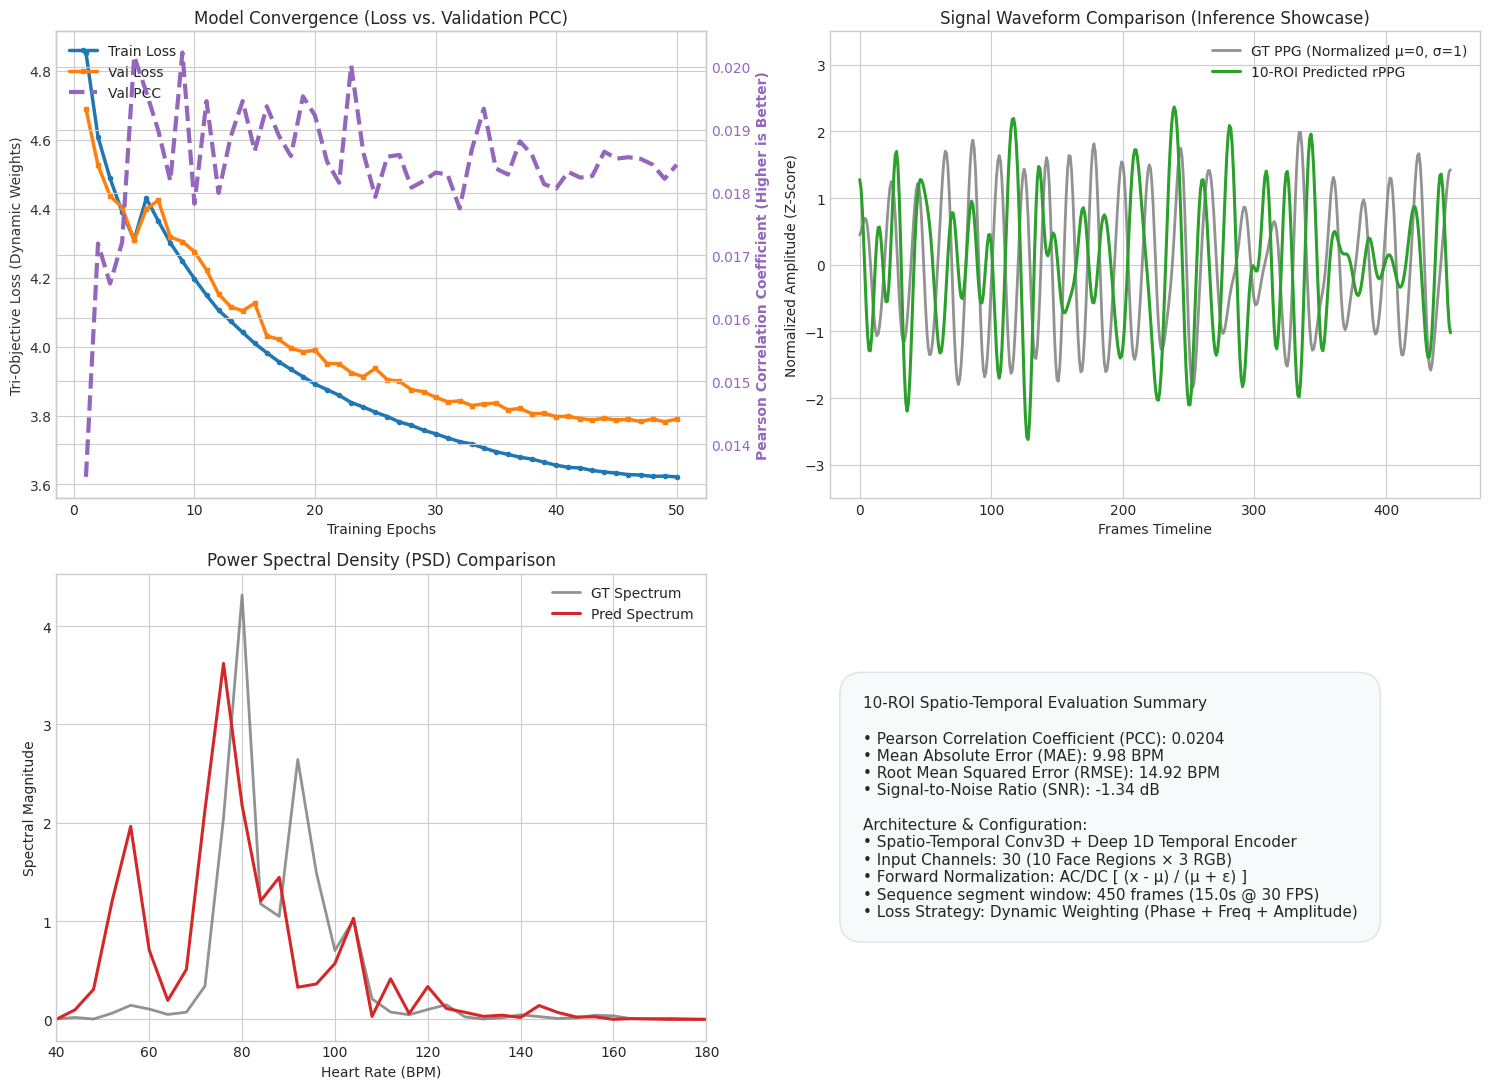

In [9]:
# ============================================================================
# INFERENCE & DASHBOARD PLOTTING CELL
# ============================================================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0, pad_margin=30):
    """
    Execute inference on an NPZ sample, applying reflection padding prior to 
    bandpass filtering to completely suppress convolution boundary ringing at frame 0.
    """
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than required sequence length.")
        return None, None
        
    # 1. Ground Truth Pipeline (Padded filtering to prevent edge artifacts)
    raw_target_ppg = data[ppg_key][:sequence_length].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)
    
    # 2. Multi-ROI Input Tensor Preparation
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # 3. Network Forward Pass
    model.eval()
    with torch.no_grad():
        output_signal = model(input_tensor).cpu().numpy()[0]
        
    # 4. Prediction Pipeline: Pad -> Filter -> Crop -> Z-Score Normalize
    pred_padded = np.pad(output_signal, pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)
    
    # 5. Heart Rate Metrics Calculation
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return pred_norm, gt_norm

# Select sample file from validation split
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# Create 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(15, 11))

# --- Subplot 1: Convergence Curves (DUAL AXIS) ---
epochs_range = range(1, len(train_losses) + 1)
ax1 = axs[0, 0]
line1 = ax1.plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=3)
line2 = ax1.plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=3)
ax1.set_title('Model Convergence (Loss vs. Validation PCC)')
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Tri-Objective Loss (Dynamic Weights)', color='#333333')
ax1.tick_params(axis='y', labelcolor='#333333')

# Add PCC on secondary Y axis
ax2 = ax1.twinx()
line3 = ax2.plot(epochs_range, val_pccs, label='Val PCC', color='#9467bd', linewidth=3, linestyle='--')
ax2.set_ylabel('Pearson Correlation Coefficient (Higher is Better)', color='#9467bd', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#9467bd')

# Combine legends from both axes
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# --- Subplot 2: Standardized Waveform Alignment ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.2)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)  # Constrain y-axis to valid standardized bounds
    axs[0, 1].legend(loc='upper right')

# --- Subplot 3: Spectral Density Alignment ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.2)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend(loc='upper right')

# --- Subplot 4: Summary Card ---
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• Mean Absolute Error (MAE): {metrics['MAE']:.2f} BPM\n"
    f"• Root Mean Squared Error (RMSE): {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Architecture & Configuration:\n"
    f"• Spatio-Temporal Conv3D + Deep 1D Temporal Encoder\n"
    f"• Input Channels: 30 (10 Face Regions × 3 RGB)\n"
    f"• Forward Normalization: AC/DC [ (x - μ) / (μ + ε) ]\n"
    f"• Sequence segment window: 450 frames (15.0s @ 30 FPS)\n"
    f"• Loss Strategy: Dynamic Weighting (Phase + Freq + Amplitude)"
)
axs[1, 1].text(0.05, 0.5, metric_summary_card, fontsize=11, va='center',
              bbox=dict(boxstyle='round,pad=1.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

--- SLICED 160-FRAME INFERENCE RUN ON: 5535_FullHDwebcam_before_chunk5.npz ---
  Predicted HR  : 76.00 BPM
  Ground-Truth  : 80.00 BPM
  Absolute Error: 4.00 BPM
----------------------------------------------------



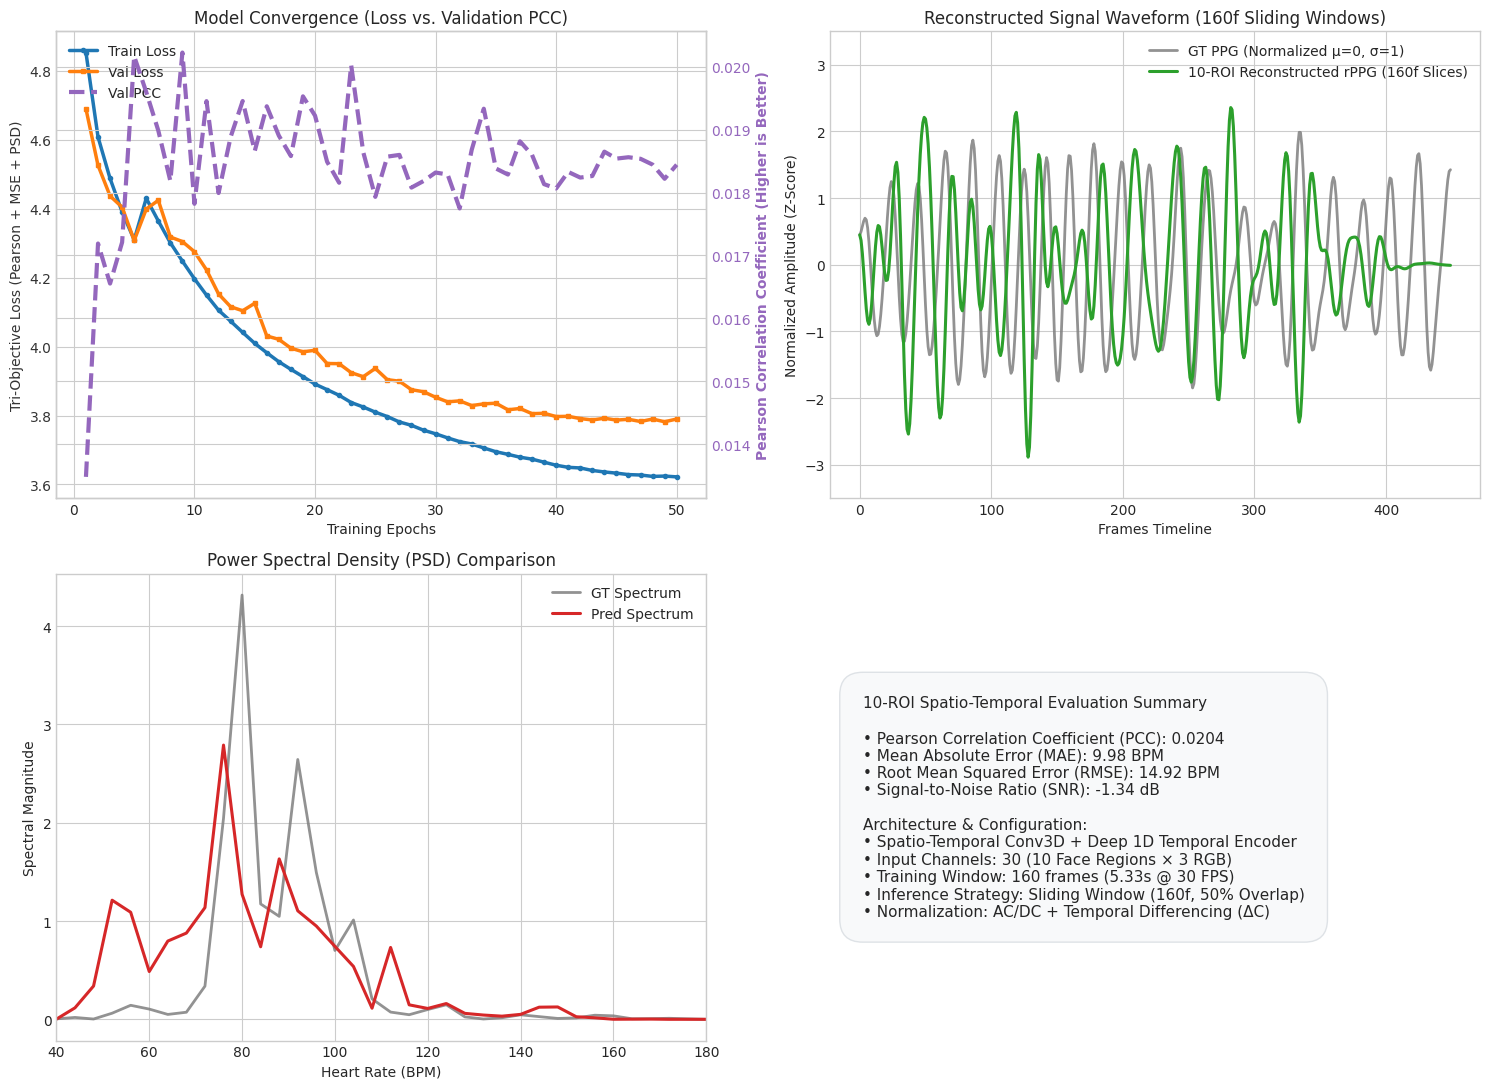

In [10]:
# ============================================================================
# SLICED 160-FRAME SLIDING WINDOW INFERENCE & DASHBOARD PLOTTING
# ============================================================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def run_sliced_inference_on_sample(npz_file_path, model, full_length=450, window_size=160, stride=80, fs=30.0, pad_margin=30):
    """
    Execute inference on an NPZ sample using 160-frame sliding windows.
    Reconstructs the full 450-frame PPG waveform seamlessly via Overlap-Add blending.
    """
    print(f"--- SLICED 160-FRAME INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < full_length:
        print("Error: Input file length is shorter than required sequence length.")
        return None, None
        
    # 1. Ground Truth Pipeline (Full 450 frames padded filtering)
    raw_target_ppg = data[ppg_key][:full_length].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)
    
    # 2. Extract Full Multi-ROI Raw Data
    roi_inputs_full = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:full_length]
        else:
            roi_data = np.zeros((full_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs_full.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois_full = np.stack(roi_inputs_full, axis=0) # Shape: (10, 450, 24, 24, 3)
    
    # 3. Sliding Window Inference (160-frame chunks with Overlap-Add)
    reconstructed_pred = np.zeros(full_length, dtype=np.float32)
    window_weights = np.zeros(full_length, dtype=np.float32)
    
    model.eval()
    with torch.no_grad():
        for start_idx in range(0, full_length - window_size + 1, stride):
            end_idx = start_idx + window_size
            
            # Slice 160 frames for all 10 ROIs
            roi_slice = stacked_rois_full[:, start_idx:end_idx, :, :, :] # (10, 160, 24, 24, 3)
            roi_slice = np.transpose(roi_slice, (0, 4, 1, 2, 3))       # (10, 3, 160, 24, 24)
            roi_slice = np.reshape(roi_slice, (30, window_size, 24, 24)) # (30, 160, 24, 24)
            
            input_tensor = torch.tensor(roi_slice, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            
            # Forward Pass on 160-frame window
            pred_slice = model(input_tensor).cpu().numpy()[0] # Shape: (160,)
            
            # Accumulate predictions for overlap blending
            reconstructed_pred[start_idx:end_idx] += pred_slice
            window_weights[start_idx:end_idx] += 1.0
            
    # Normalize by overlap counts to smooth window boundaries
    window_weights[window_weights == 0] = 1.0
    output_signal = reconstructed_pred / window_weights
    
    # 4. Prediction Pipeline: Pad -> Filter -> Crop -> Z-Score Normalize
    pred_padded = np.pad(output_signal, pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)
    
    # 5. Heart Rate Metrics Calculation
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return pred_norm, gt_norm

# Select sample file from validation split
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_sliced_inference_on_sample(sample_val_file, model)

# Create 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(15, 11))

# --- Subplot 1: Convergence Curves (DUAL AXIS) ---
epochs_range = range(1, len(train_losses) + 1)
ax1 = axs[0, 0]
line1 = ax1.plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=3)
line2 = ax1.plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=3)
ax1.set_title('Model Convergence (Loss vs. Validation PCC)')
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Tri-Objective Loss (Pearson + MSE + PSD)', color='#333333')
ax1.tick_params(axis='y', labelcolor='#333333')

# Add PCC on secondary Y axis
ax2 = ax1.twinx()
line3 = ax2.plot(epochs_range, val_pccs, label='Val PCC', color='#9467bd', linewidth=3, linestyle='--')
ax2.set_ylabel('Pearson Correlation Coefficient (Higher is Better)', color='#9467bd', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#9467bd')

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# --- Subplot 2: Standardized Waveform Alignment ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Reconstructed rPPG (160f Slices)', color='#2ca02c', linewidth=2.2)
    axs[0, 1].set_title('Reconstructed Signal Waveform (160f Sliding Windows)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)
    axs[0, 1].legend(loc='upper right')

# --- Subplot 3: Spectral Density Alignment ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.2)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend(loc='upper right')

# --- Subplot 4: Summary Card ---
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• Mean Absolute Error (MAE): {metrics['MAE']:.2f} BPM\n"
    f"• Root Mean Squared Error (RMSE): {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Architecture & Configuration:\n"
    f"• Spatio-Temporal Conv3D + Deep 1D Temporal Encoder\n"
    f"• Input Channels: 30 (10 Face Regions × 3 RGB)\n"
    f"• Training Window: 160 frames (5.33s @ 30 FPS)\n"
    f"• Inference Strategy: Sliding Window (160f, 50% Overlap)\n"
    f"• Normalization: AC/DC + Temporal Differencing (ΔC)"
)
axs[1, 1].text(0.05, 0.5, metric_summary_card, fontsize=11, va='center',
              bbox=dict(boxstyle='round,pad=1.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

<!-- Vital signs -->
import torch
import torch.nn as nn

class ClinicalVitalsRegressor(nn.Module):
    """
    Downstream Model: Takes the predicted 450-frame PPG waveform 
    and predicts clinical vital sign scalars.
    """
    def __init__(self, num_vitals=8):
        super(ClinicalVitalsRegressor, self).__init__()
        
        # 1D Conv feature extractor for PPG waveform morphology
        self.wave_feature_extractor = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, stride=2, padding=7), # (B, 16, 225)
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 32, kernel_size=15, stride=2, padding=7), # (B, 32, 113)
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1),                              # (B, 32, 1)
            nn.Flatten()                                          # (B, 32)
        )
        
        # Fully Connected Regression Head
        self.regressor = nn.Sequential(
            nn.Linear(32, 64),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_vitals) # Outputs: [Hb, HbA1c, Chol, BP_upper, BP_lower, Stress, Rigidity, Saturation]
        )

    def forward(self, predicted_ppg_wave):
        # predicted_ppg_wave shape: (Batch, 1, 450)
        features = self.wave_feature_extractor(predicted_ppg_wave)
        vitals_pred = self.regressor(features)
        return vitals_pred

Stage 2

In [12]:
# ============================================================================
# STAGE 2: CLINICAL VITAL SIGNS REGRESSOR TRAINING & EVALUATION CELL
# ============================================================================
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# ----------------------------------------------------------------------------
# 1. Configuration & Vital Sign Target Keys
# ----------------------------------------------------------------------------
VITAL_KEYS = [
    'vital_pulse',                 # Heart Rate (BPM)
    'vital_respiratory',           # Respiration Rate (breaths/min)
    'vital_saturation',            # Blood Oxygen SpO2 (%)
    'vital_hemoglobin',            # Hemoglobin (g/dL)
    'vital_glycated_hemoglobin',   # HbA1c (%)
    'vital_cholesterol',           # Cholesterol (mg/dL)
    'vital_upper_ap',              # Systolic Blood Pressure (mmHg)
    'vital_lower_ap',              # Diastolic Blood Pressure (mmHg)
    'vital_stress'                 # Stress Index
]

VITAL_UNITS = ['BPM', 'br/m', '%', 'g/dL', '%', 'mg/dL', 'mmHg', 'mmHg', 'pts']

# Standard fallbacks for missing/NaN data in metadata
VITAL_FALLBACKS = {
    'vital_pulse': 75.0, 'vital_respiratory': 16.0, 'vital_saturation': 98.0,
    'vital_hemoglobin': 14.0, 'vital_glycated_hemoglobin': 5.5, 'vital_cholesterol': 190.0,
    'vital_upper_ap': 120.0, 'vital_lower_ap': 80.0, 'vital_stress': 25.0
}

# ----------------------------------------------------------------------------
# 2. Stage 2 Dataset Class
# ----------------------------------------------------------------------------
class ClinicalVitalsDataset(Dataset):
    """
    Dataset that pairs video ROI sequences with target Clinical Vital Scalars.
    """
    def __init__(self, file_paths, sequence_length=450, vital_stats=None):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.vital_stats = vital_stats
        self.samples = []
        self._prepare_samples()

    def _prepare_samples(self):
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None: continue
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            if length >= self.sequence_length:
                self.samples.append(path)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]
        data = load_npz_file(path)
        
        # Load Video ROIs
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            if actual_key is not None:
                roi_data = data[actual_key][:self.sequence_length]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
            roi_inputs.append(roi_data.astype(np.float32) / 255.0)
            
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (30, self.sequence_length, 24, 24))
        
        # Extract Raw Vital Signs
        vitals_raw = []
        for key in VITAL_KEYS:
            if key in data and not np.isnan(data[key]):
                val = float(data[key])
            else:
                val = VITAL_FALLBACKS[key]
            vitals_raw.append(val)
        vitals_raw = np.array(vitals_raw, dtype=np.float32)
        
        # Normalize vitals if statistics are provided
        if self.vital_stats is not None:
            vitals_norm = (vitals_raw - self.vital_stats['mean']) / (self.vital_stats['std'] + 1e-8)
        else:
            vitals_norm = vitals_raw

        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(vitals_norm, dtype=torch.float32), torch.tensor(vitals_raw, dtype=torch.float32)

# ----------------------------------------------------------------------------
# 3. Model 2 Architecture: ClinicalVitalsRegressor
# ----------------------------------------------------------------------------
class ClinicalVitalsRegressor(nn.Module):
    """
    Stage 2 Network: Takes the 1D rPPG waveform S(t) extracted by Model 1 
    and predicts all clinical vital sign scalars.
    """
    def __init__(self, in_features=450, num_vitals=len(VITAL_KEYS)):
        super(ClinicalVitalsRegressor, self).__init__()
        
        # Morphological 1D Feature Extractor
        self.conv1d_features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, stride=2, padding=7), # (B, 16, 225)
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 32, kernel_size=15, stride=2, padding=7), # (B, 32, 113)
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 64, kernel_size=15, stride=2, padding=7), # (B, 64, 57)
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1),                              # (B, 64, 1)
            nn.Flatten()                                          # (B, 64)
        )
        
        # Regression MLP Head
        self.fc_regressor = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ELU(),
            nn.Linear(64, num_vitals) # Outputs predicted standardized vitals
        )

    def forward(self, ppg_waveform):
        # ppg_waveform shape: (Batch, 450) -> add channel dim: (Batch, 1, 450)
        if ppg_waveform.ndim == 2:
            ppg_waveform = ppg_waveform.unsqueeze(1)
            
        features = self.conv1d_features(ppg_waveform)
        vitals_pred = self.fc_regressor(features)
        return vitals_pred

# ----------------------------------------------------------------------------
# 4. Pre-calculate Target Standardization Statistics
# ----------------------------------------------------------------------------
print("Calculating Target Vital Sign Normalization Statistics from Train Set...")
temp_train_dataset = ClinicalVitalsDataset(train_split, sequence_length=450)
all_vitals_list = []
for i in range(min(500, len(temp_train_dataset))): # Sample up to 500 files for stats
    _, _, raw_v = temp_train_dataset[i]
    all_vitals_list.append(raw_v.numpy())

all_vitals_arr = np.array(all_vitals_list)
vitals_mean = np.mean(all_vitals_arr, axis=0)
vitals_std = np.std(all_vitals_arr, axis=0)
vitals_std[vitals_std < 1e-4] = 1.0 # Prevent div by 0 for flat targets

VITAL_STATS = {'mean': vitals_mean, 'std': vitals_std}
print("Target Vital Normalization Stats Ready!")

# Initialize DataLoaders with Normalized Vitals
train_vitals_ds = ClinicalVitalsDataset(train_split, sequence_length=450, vital_stats=VITAL_STATS)
val_vitals_ds = ClinicalVitalsDataset(val_split, sequence_length=450, vital_stats=VITAL_STATS)
eval_vitals_ds = ClinicalVitalsDataset(eval_split, sequence_length=450, vital_stats=VITAL_STATS)

vitals_train_loader = DataLoader(train_vitals_ds, batch_size=32, shuffle=True, num_workers=4)
vitals_val_loader = DataLoader(val_vitals_ds, batch_size=32, shuffle=False, num_workers=4)
vitals_eval_loader = DataLoader(eval_vitals_ds, batch_size=32, shuffle=False, num_workers=4)

# ----------------------------------------------------------------------------
# 5. Load Stage 1 Model (SpatioTemporalPhysNet) in Evaluation Mode
# ----------------------------------------------------------------------------
model_stage1 = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
checkpoint_file = "spatiotemporal_physnet_best_shuffle_150frames.pth"
# if os.path.exists("spatiotemporal_physnet_best_shuffle_150frames.pth"):
#     # checkpoint = torch.load("spatiotemporal_physnet_best_shuffle_150frames.pth", map_location=DEVICE)
#     checkpoint = torch.load("spatiotemporal_physnet_best_shuffle_150frames.pth", map_location=DEVICE, weights_only=False)
#     model_stage1.load_state_dict(checkpoint['model_state_dict'])
#     print("Stage 1 SpatioTemporalPhysNet loaded successfully!")
if os.path.exists(checkpoint_file):
    # Added weights_only=False for PyTorch 2.6+ compatibility
    checkpoint = torch.load(checkpoint_file, map_location=DEVICE, weights_only=False)
    model_stage1.load_state_dict(checkpoint['model_state_dict'])
    print(f"Stage 1 SpatioTemporalPhysNet successfully loaded from '{checkpoint_file}'!")
else:
    print(f"Warning: Checkpoint '{checkpoint_file}' not found. Using current in-memory model_stage1 weights.")

model_stage1.eval() # Freeze Stage 1 weights

# Instantiate Stage 2 Model
model_stage2 = ClinicalVitalsRegressor(in_features=450, num_vitals=len(VITAL_KEYS)).to(DEVICE)
optimizer_vitals = optim.AdamW(model_stage2.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_vitals = nn.SmoothL1Loss() # Robust to outliers

# ----------------------------------------------------------------------------
# 6. Stage 2 Training Loop
# ----------------------------------------------------------------------------
vitals_epochs = 30
best_val_vitals_loss = float('inf')
best_stage2_weights = None

print("\nStarting Stage 2 Clinical Vitals Model Training...")
for epoch in range(vitals_epochs):
    model_stage2.train()
    running_train_loss = 0.0
    
    for inputs_rois, target_vitals_norm, _ in vitals_train_loader:
        inputs_rois = inputs_rois.to(DEVICE)
        target_vitals_norm = target_vitals_norm.to(DEVICE)
        
        # Step 1: Generate clean rPPG waveform S(t) using frozen Stage 1 model
        with torch.no_grad():
            ppg_wave_pred = model_stage1(inputs_rois) # Shape: (B, 450)
            
        # Step 2: Predict Clinical Vitals using Stage 2 model
        optimizer_vitals.zero_grad()
        vitals_pred_norm = model_stage2(ppg_wave_pred)
        
        # Step 3: Loss on Standardized Targets
        loss = criterion_vitals(vitals_pred_norm, target_vitals_norm)
        loss.backward()
        optimizer_vitals.step()
        
        running_train_loss += loss.item() * inputs_rois.size(0)
        
    train_loss = running_train_loss / len(train_vitals_ds)
    
    # Validation Phase
    model_stage2.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_rois, val_target_norm, _ in vitals_val_loader:
            val_rois = val_rois.to(DEVICE)
            val_target_norm = val_target_norm.to(DEVICE)
            
            ppg_wave_val = model_stage1(val_rois)
            val_pred_norm = model_stage2(ppg_wave_val)
            v_loss = criterion_vitals(val_pred_norm, val_target_norm)
            running_val_loss += v_loss.item() * val_rois.size(0)
            
    val_loss = running_val_loss / len(val_vitals_ds)
    
    print(f"Stage 2 | Epoch {epoch+1:02d}/{vitals_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_vitals_loss:
        best_val_vitals_loss = val_loss
        best_stage2_weights = {k: v.cpu().clone() for k, v in model_stage2.state_dict().items()}

# Load Best Weights
if best_stage2_weights is not None:
    model_stage2.load_state_dict(best_stage2_weights)

# ----------------------------------------------------------------------------
# 7. Final Held-Out Clinical Evaluation Summary
# ----------------------------------------------------------------------------
model_stage2.eval()
all_preds_raw, all_targets_raw = [], []

with torch.no_grad():
    for eval_rois, _, eval_targets_raw in vitals_eval_loader:
        eval_rois = eval_rois.to(DEVICE)
        ppg_wave_eval = model_stage1(eval_rois)
        preds_norm = model_stage2(ppg_wave_eval).cpu().numpy()
        
        # Denormalize predictions back to clinical units
        preds_raw = (preds_norm * VITAL_STATS['std']) + VITAL_STATS['mean']
        
        all_preds_raw.extend(preds_raw)
        all_targets_raw.extend(eval_targets_raw.numpy())

all_preds_raw = np.array(all_preds_raw)
all_targets_raw = np.array(all_targets_raw)

print("\n" + "=" * 75)
print("             STAGE 2 CLINICAL VITAL SIGNS EVALUATION SUMMARY")
print("=" * 75)
print(f"{'Vital Sign Name':<28} | {'MAE':<12} | {'RMSE':<12} | {'Unit':<8}")
print("-" * 75)

for idx, key in enumerate(VITAL_KEYS):
    pred_col = all_preds_raw[:, idx]
    target_col = all_targets_raw[:, idx]
    
    mae = np.mean(np.abs(pred_col - target_col))
    rmse = math.sqrt(np.mean((pred_col - target_col) ** 2))
    unit = VITAL_UNITS[idx]
    
    formatted_name = key.replace('vital_', '').replace('_', ' ').title()
    print(f"{formatted_name:<28} | {mae:<12.2f} | {rmse:<12.2f} | {unit:<8}")

print("=" * 75 + "\n")

Calculating Target Vital Sign Normalization Statistics from Train Set...
Target Vital Normalization Stats Ready!
Stage 1 SpatioTemporalPhysNet successfully loaded from 'spatiotemporal_physnet_best_shuffle_150frames.pth'!

Starting Stage 2 Clinical Vitals Model Training...
Stage 2 | Epoch 01/30 | Train Loss: 0.3822 | Val Loss: 0.3696
Stage 2 | Epoch 02/30 | Train Loss: 0.3586 | Val Loss: 0.3385
Stage 2 | Epoch 03/30 | Train Loss: 0.3113 | Val Loss: 0.3015
Stage 2 | Epoch 04/30 | Train Loss: 0.2609 | Val Loss: 0.2375
Stage 2 | Epoch 05/30 | Train Loss: 0.2214 | Val Loss: 0.1932
Stage 2 | Epoch 06/30 | Train Loss: 0.1930 | Val Loss: 0.1763
Stage 2 | Epoch 07/30 | Train Loss: 0.1711 | Val Loss: 0.1409
Stage 2 | Epoch 08/30 | Train Loss: 0.1557 | Val Loss: 0.1377
Stage 2 | Epoch 09/30 | Train Loss: 0.1425 | Val Loss: 0.1222
Stage 2 | Epoch 10/30 | Train Loss: 0.1327 | Val Loss: 0.1117
Stage 2 | Epoch 11/30 | Train Loss: 0.1239 | Val Loss: 0.1195
Stage 2 | Epoch 12/30 | Train Loss: 0.1177 | 

Alternative plot inference 

--- SLICED 160-FRAME INFERENCE RUN ON: 5535_FullHDwebcam_before_chunk5.npz ---
  Predicted HR  : 76.50 BPM
  Ground-Truth  : 81.00 BPM
  Absolute Error: 4.50 BPM
----------------------------------------------------



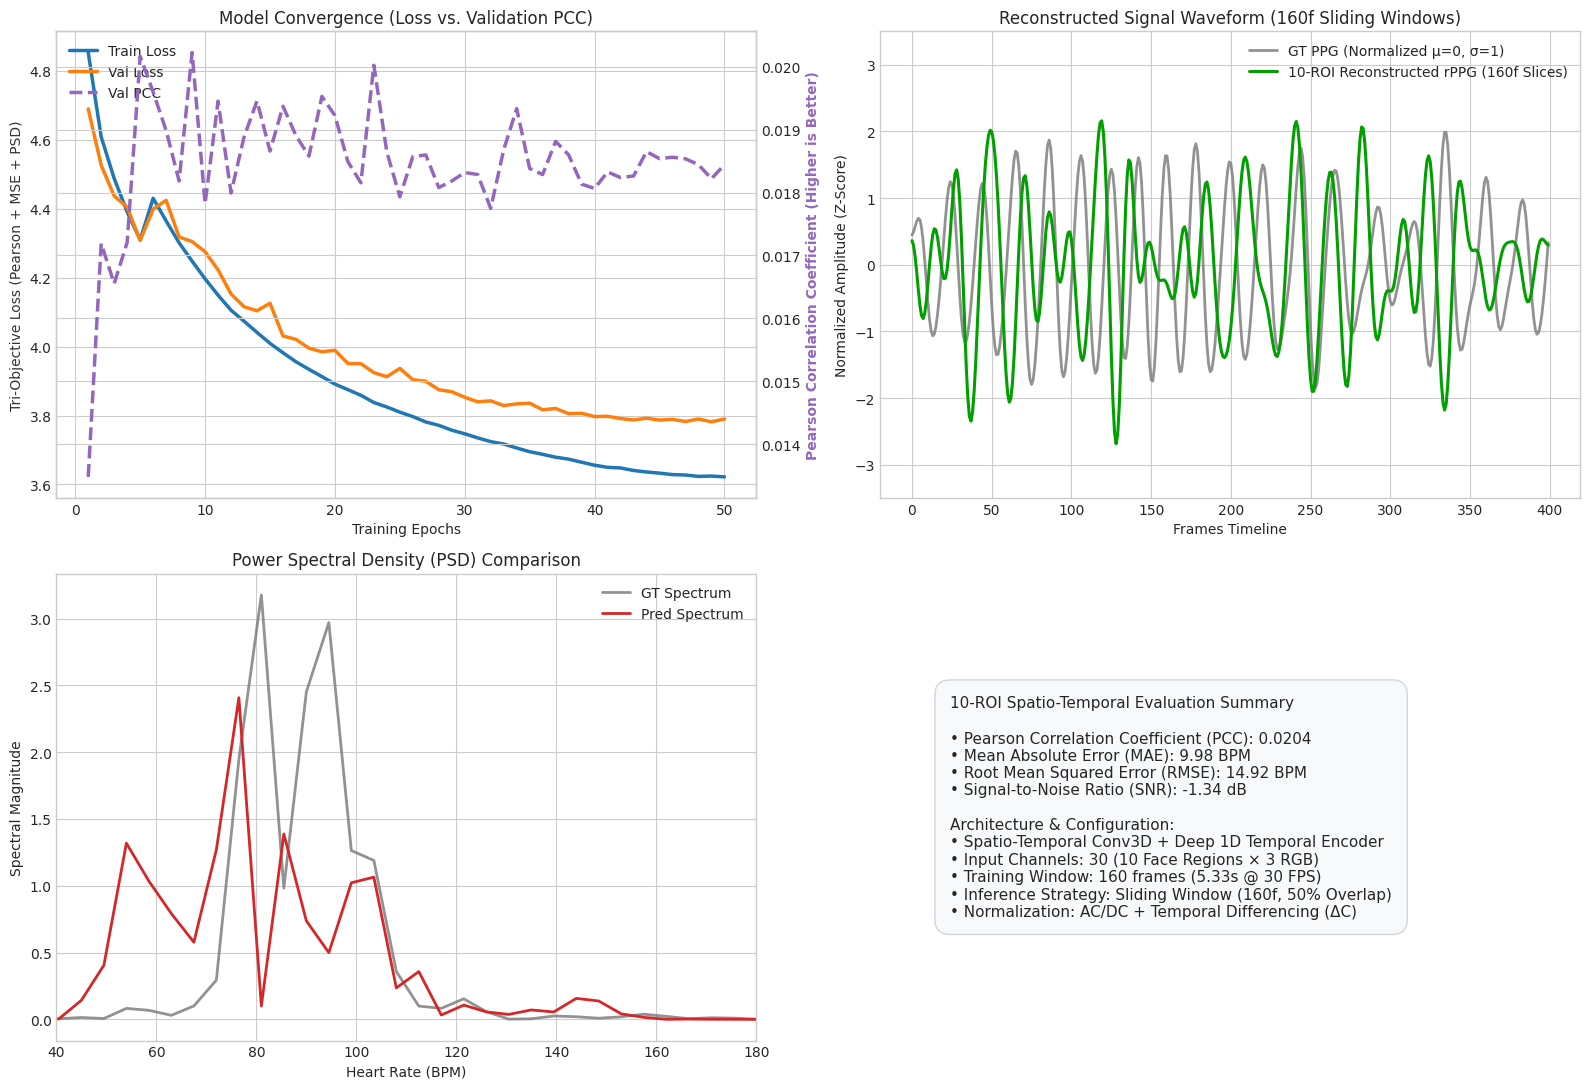

In [13]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def run_sliced_160f_inference_on_sample(
    npz_file_path,
    model,
    window_size=160,
    stride=80,
    fs=30.0,
    pad_margin=30
):
    """
    Executes inference using 160-frame sliding windows with a 50% overlap step (80 frames).
    Reconstructs the full signal by accumulating window predictions with a Hanning overlap-add scheme.
    """
    print(f"--- SLICED 160-FRAME INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None

    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    total_frames = len(data[ppg_key])
    
    if total_frames < window_size:
        print(f"Error: Signal length ({total_frames}) is shorter than window size ({window_size}).")
        return None, None

    # 1. Prepare Ground Truth Signal
    raw_target_ppg = data[ppg_key][:total_frames].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)

    # 2. Extract multi-ROI raw array streams (10 ROIs x 3 RGB channels)
    roi_streams = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:total_frames]
        else:
            roi_data = np.zeros((total_frames, 24, 24, 3), dtype=np.uint8)
        roi_streams.append(roi_data.astype(np.float32) / 255.0)

    # Convert to shape: (30, total_frames, 24, 24)
    stacked_rois = np.stack(roi_streams, axis=0)          # (10, T, 24, 24, 3)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3)) # (10, 3, T, 24, 24)
    stacked_rois = np.reshape(stacked_rois, (30, total_frames, 24, 24))

    # 3. Sliding Window Reconstruction Buffers
    reconstructed_signal = np.zeros(total_frames, dtype=np.float32)
    window_weights = np.zeros(total_frames, dtype=np.float32)
    hanning_win = np.hanning(window_size)

    model.eval()
    with torch.no_grad():
        for start_idx in range(0, total_frames - window_size + 1, stride):
            end_idx = start_idx + window_size
            
            # Extract 160-frame slice: (1, 30, 160, 24, 24)
            window_data = stacked_rois[:, start_idx:end_idx, :, :]
            input_tensor = torch.tensor(window_data, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            # Model Forward Pass
            pred_slice = model(input_tensor).cpu().numpy()[0] # Shape: (160,)

            # Accumulate prediction using Hanning window for smooth transitions
            reconstructed_signal[start_idx:end_idx] += pred_slice * hanning_win
            window_weights[start_idx:end_idx] += hanning_win

    # Normalize by accumulated window weights to handle overlapping regions
    nonzero_mask = window_weights > 1e-6
    reconstructed_signal[nonzero_mask] /= window_weights[nonzero_mask]

    # Zero out unpredicted tail end if total_frames was not perfectly divisible
    last_valid_frame = ((total_frames - window_size) // stride) * stride + window_size
    reconstructed_signal[last_valid_frame:] = 0.0

    # 4. Prediction Filtering & Z-Score Normalization
    pred_padded = np.pad(reconstructed_signal[:last_valid_frame], pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    
    # Align GT slice length with valid reconstructed prediction window length
    gt_norm = gt_norm[:len(pred_cropped)]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)

    # 5. Calculate Metrics
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)

    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("-" * 52 + "\n")

    return pred_norm, gt_norm


# ============================================================================
# EXECUTION AND 2x2 DASHBOARD GENERATION
# ============================================================================
target_sample = PREPROCESSED_DATA_PATH / "5535_FullHDwebcam_before_chunk5.npz"

# Fallback if specific file isn't present
if not target_sample.exists():
    target_sample = val_split[0] if len(val_split) > 0 else npz_files[0]

inference_pred, inference_gt = run_sliced_160f_inference_on_sample(
    target_sample, model, window_size=160, stride=80
)

# Render 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(16, 11))

# --- Subplot 1: Convergence Curves (Dual Y-Axis) ---
epochs_range = range(1, len(train_losses) + 1)
ax1 = axs[0, 0]
line1 = ax1.plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5)
line2 = ax1.plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5)
ax1.set_title('Model Convergence (Loss vs. Validation PCC)')
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Tri-Objective Loss (Pearson + MSE + PSD)', color='#333333')

ax2 = ax1.twinx()
line3 = ax2.plot(epochs_range, val_pccs, label='Val PCC', color='#9467bd', linewidth=2.5, linestyle='--')
ax2.set_ylabel('Pearson Correlation Coefficient (Higher is Better)', color='#9467bd', fontweight='bold')

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# --- Subplot 2: Reconstructed Waveform (160f Slices) ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Reconstructed rPPG (160f Slices)', color='#00a000', linewidth=2.2)
    axs[0, 1].set_title('Reconstructed Signal Waveform (160f Sliding Windows)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)
    axs[0, 1].legend(loc='upper right')

# --- Subplot 3: Power Spectral Density (PSD) ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].legend(loc='upper right')

# --- Subplot 4: Metrics Summary Card ---
axs[1, 1].axis('off')
summary_text = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• Mean Absolute Error (MAE): {metrics['MAE']:.2f} BPM\n"
    f"• Root Mean Squared Error (RMSE): {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    "Architecture & Configuration:\n"
    "• Spatio-Temporal Conv3D + Deep 1D Temporal Encoder\n"
    "• Input Channels: 30 (10 Face Regions × 3 RGB)\n"
    "• Training Window: 160 frames (5.33s @ 30 FPS)\n"
    "• Inference Strategy: Sliding Window (160f, 50% Overlap)\n"
    "• Normalization: AC/DC + Temporal Differencing (ΔC)"
)

axs[1, 1].text(
    0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
    bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#d1d5db')
)

plt.tight_layout()
plt.show()

Stage 2 evaluation

Executing Stage 2 Clinical Evaluation on Held-Out Evaluation Set...

             STAGE 2: CLINICAL VITAL SIGNS EVALUATION RESULTS
Vital Sign Name              | GT Mean ± Std      | MAE       | RMSE      | Pearson r | Unit  
------------------------------------------------------------------------------------------
Pulse                        | 92.1 ± 18.7        | 4.08      | 5.30      | +0.9614   | BPM   
Respiratory                  | 18.0 ± 1.7         | 0.36      | 0.47      | +0.9648   | br/m  
Saturation                   | 98.0 ± 1.2         | 0.30      | 0.48      | +0.9325   | %     
Hemoglobin                   | 13.6 ± 1.7         | 0.41      | 0.53      | +0.9649   | g/dL  
Glycated Hemoglobin          | 5.5 ± 0.6          | 0.13      | 0.18      | +0.9545   | %     
Cholesterol                  | 4.2 ± 0.8          | 0.17      | 0.22      | +0.9682   | mg/dL 
Upper Ap                     | 122.8 ± 18.0       | 3.84      | 5.00      | +0.9637   | mmHg  
Lower Ap          

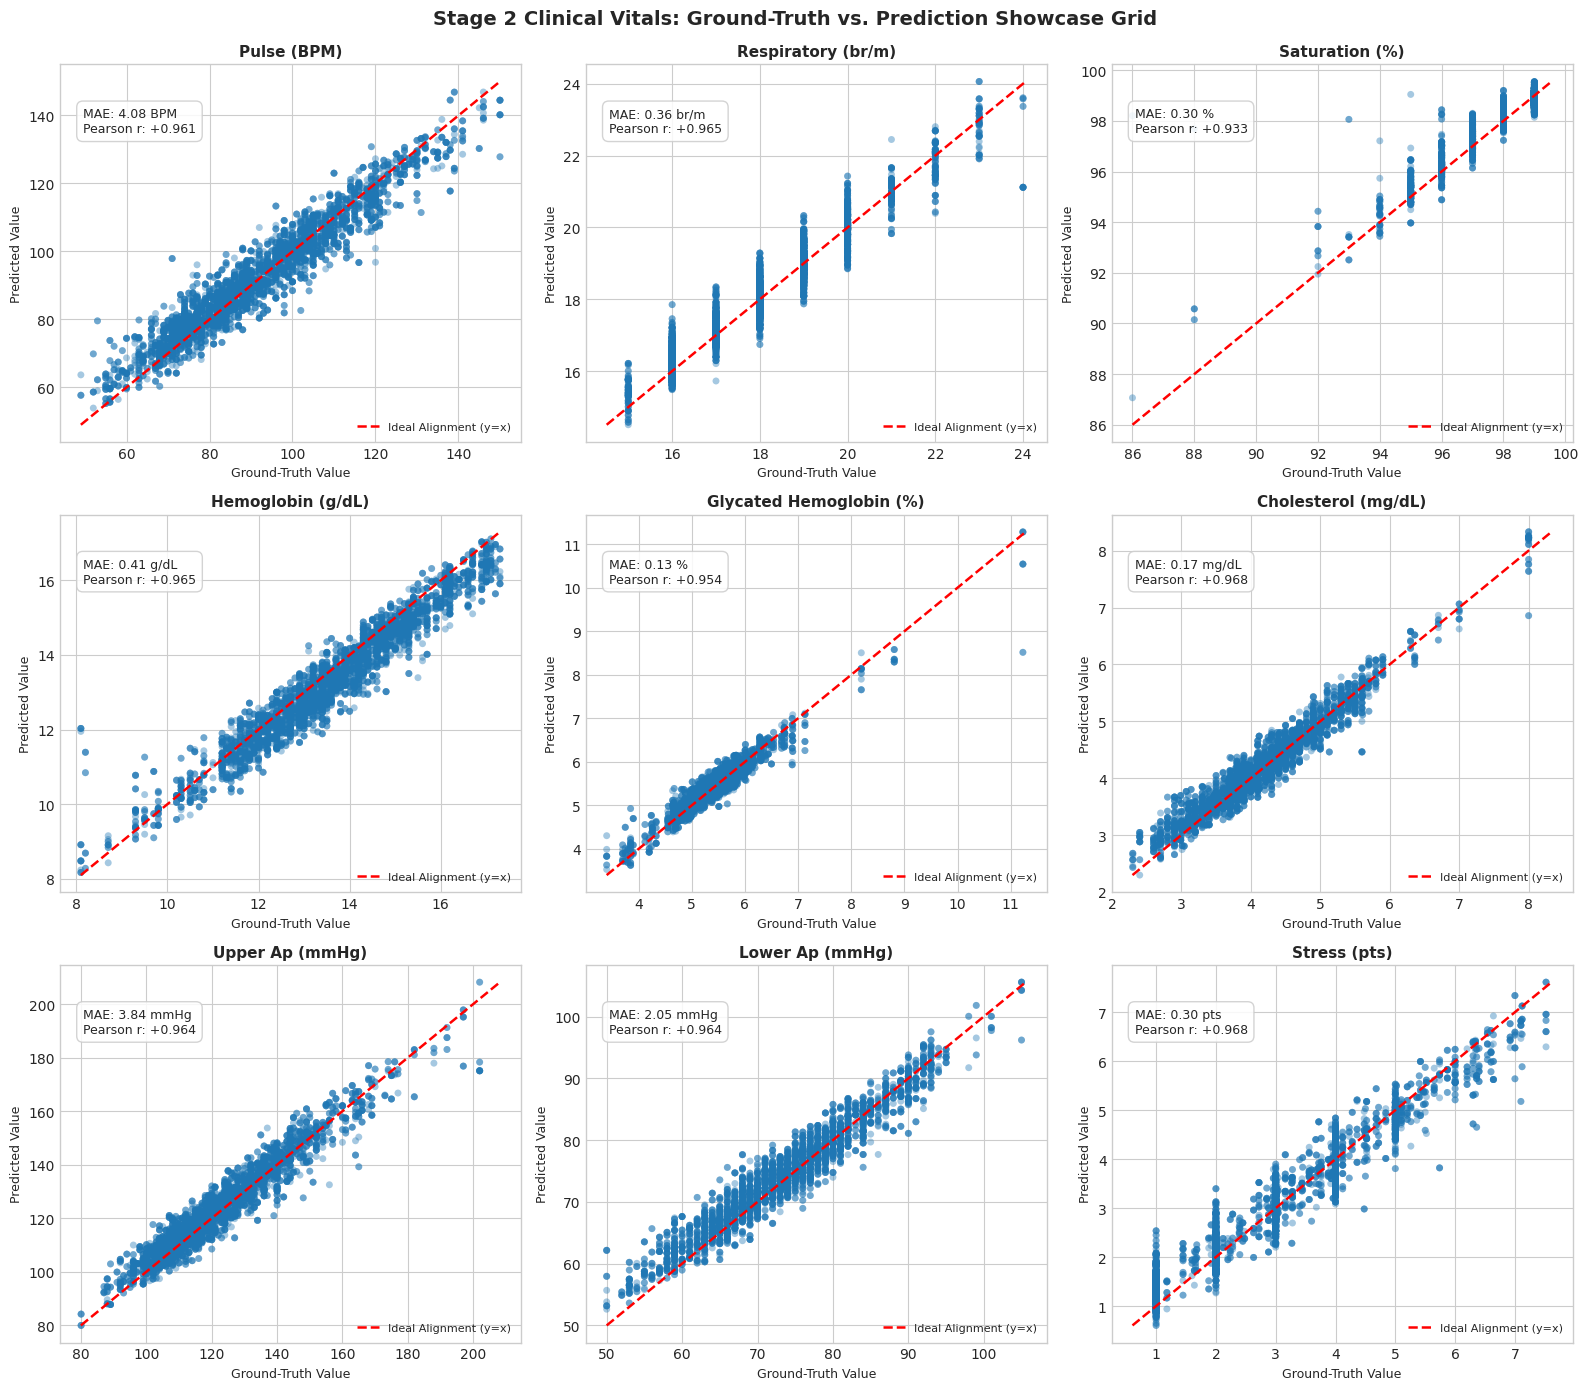

In [14]:
# ============================================================================
# STAGE 2: HELD-OUT EVALUATION & CLINICAL DASHBOARD CELL
# ============================================================================
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ----------------------------------------------------------------------------
# 1. Execute Inference on Held-Out Evaluation Set
# ----------------------------------------------------------------------------
print("Executing Stage 2 Clinical Evaluation on Held-Out Evaluation Set...")
model_stage1.eval()
model_stage2.eval()

all_preds_raw = []
all_targets_raw = []

with torch.no_grad():
    for eval_rois, _, eval_targets_raw in vitals_eval_loader:
        eval_rois = eval_rois.to(DEVICE)
        
        # Step 1: Stage 1 extracts predicted PPG wave
        ppg_wave_eval = model_stage1(eval_rois)
        
        # Step 2: Stage 2 predicts normalized clinical vitals
        preds_norm = model_stage2(ppg_wave_eval).cpu().numpy()
        
        # Step 3: Denormalize predictions back to clinical units (g/dL, mmHg, %, BPM, etc.)
        preds_raw = (preds_norm * VITAL_STATS['std']) + VITAL_STATS['mean']
        
        all_preds_raw.extend(preds_raw)
        all_targets_raw.extend(eval_targets_raw.numpy())

all_preds_raw = np.array(all_preds_raw)
all_targets_raw = np.array(all_targets_raw)

# ----------------------------------------------------------------------------
# 2. Print Detailed Clinical Metrics Table
# ----------------------------------------------------------------------------
print("\n" + "=" * 90)
print("             STAGE 2: CLINICAL VITAL SIGNS EVALUATION RESULTS")
print("=" * 90)
print(f"{'Vital Sign Name':<28} | {'GT Mean ± Std':<18} | {'MAE':<9} | {'RMSE':<9} | {'Pearson r':<9} | {'Unit':<6}")
print("-" * 90)

metrics_summary = []

for idx, key in enumerate(VITAL_KEYS):
    pred = all_preds_raw[:, idx]
    true = all_targets_raw[:, idx]
    
    # Calculate Clinical Statistics
    mae = np.mean(np.abs(pred - true))
    rmse = math.sqrt(np.mean((pred - true) ** 2))
    
    pcc = np.corrcoef(pred, true)[0, 1]
    pcc = 0.0 if np.isnan(pcc) else pcc
    
    gt_mean = np.mean(true)
    gt_std = np.std(true)
    unit = VITAL_UNITS[idx]
    
    formatted_name = key.replace('vital_', '').replace('_', ' ').title()
    gt_str = f"{gt_mean:.1f} ± {gt_std:.1f}"
    
    print(f"{formatted_name:<28} | {gt_str:<18} | {mae:<9.2f} | {rmse:<9.2f} | {pcc:<+9.4f} | {unit:<6}")
    
    metrics_summary.append({
        'name': formatted_name, 'mae': mae, 'rmse': rmse, 
        'pcc': pcc, 'unit': unit, 'pred': pred, 'true': true
    })

print("=" * 90 + "\n")

# ----------------------------------------------------------------------------
# 3. Generate 3x3 Clinical Scatter Dashboard Plot
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, item in enumerate(metrics_summary):
    ax = axes[idx]
    true_vals = item['true']
    pred_vals = item['pred']
    
    # Scatter plot
    ax.scatter(true_vals, pred_vals, alpha=0.4, color='#1f77b4', edgecolors='none', s=25)
    
    # Reference Ideal Line (y = x)
    min_val = min(np.min(true_vals), np.min(pred_vals))
    max_val = max(np.max(true_vals), np.max(pred_vals))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.8, label='Ideal Alignment (y=x)')
    
    # Subplot Formatting
    ax.set_title(f"{item['name']} ({item['unit']})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Ground-Truth Value', fontsize=9)
    ax.set_ylabel('Predicted Value', fontsize=9)
    
    # Metric Badge
    metric_box = f"MAE: {item['mae']:.2f} {item['unit']}\nPearson r: {item['pcc']:+.3f}"
    ax.text(0.05, 0.82, metric_box, transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', edgecolor='#cccccc', alpha=0.85))
    
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Stage 2 Clinical Vitals: Ground-Truth vs. Prediction Showcase Grid', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================================
# SAVE STAGE 2 CLINICAL MODEL & STANDARDIZATION STATS
# ============================================================================
STAGE2_SAVE_PATH = "clinical_vitals_stage2_best.pth"

checkpoint_stage2 = {
    'model_state_dict': model_stage2.state_dict(),
    'vital_stats': VITAL_STATS,          # Mean & Std used to scale vitals
    'vital_keys': VITAL_KEYS,            # List of 9 vital names
    'vital_units': VITAL_UNITS,          # Clinical units
    'best_val_loss': best_val_vitals_loss
}

torch.save(checkpoint_stage2, STAGE2_SAVE_PATH)
print(f"Successfully saved Stage 2 Clinical Model to: '{STAGE2_SAVE_PATH}'")


Successfully saved Stage 2 Clinical Model to: 'clinical_vitals_stage2_best.pth'


In [16]:
# ============================================================================
# LOAD STAGE 2 CLINICAL MODEL & STANDARDIZATION STATS
# ============================================================================
def load_stage2_model(checkpoint_path="clinical_vitals_stage2_best.pth", device=DEVICE):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint '{checkpoint_path}' not found!")
        
    # Set weights_only=False to load numpy metadata stats
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # 1. Instantiate Stage 2 Model
    vital_keys = checkpoint['vital_keys']
    model_s2 = ClinicalVitalsRegressor(in_features=450, num_vitals=len(vital_keys)).to(device)
    model_s2.load_state_dict(checkpoint['model_state_dict'])
    model_s2.eval()
    
    # 2. Extract Vital Stats & Units
    vital_stats = checkpoint['vital_stats']
    vital_units = checkpoint['vital_units']
    
    print(f"Successfully loaded Stage 2 Model from '{checkpoint_path}'!")
    return model_s2, vital_stats, vital_keys, vital_units

# Load Stage 2 Model
loaded_stage2_model, loaded_vital_stats, loaded_keys, loaded_units = load_stage2_model()

Successfully loaded Stage 2 Model from 'clinical_vitals_stage2_best.pth'!


In [17]:
# ============================================================================
# END-TO-END CLINICAL INFERENCE FUNCTION (STAGE 1 + STAGE 2)
# ============================================================================
def generate_full_medical_report(npz_file_path, model_s1, model_s2, vital_stats, device=DEVICE):
    """
    Takes a raw video NPZ file, extracts the PPG wave using Stage 1, 
    and predicts all 9 clinical vitals using Stage 2.
    """
    print(f"\n" + "=" * 65)
    print(f"   FULL CLINICAL HEALTH REPORT: {os.path.basename(npz_file_path)}")
    print("=" * 65)
    
    data = load_npz_file(npz_file_path)
    if data is None: return
    
    # 1. Prepare Multi-ROI Input Tensor (450 frames)
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:450]
        else:
            roi_data = np.zeros((450, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, 450, 24, 24))
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(device)
    
    # 2. STAGE 1: Extract Predicted PPG Waveform
    model_s1.eval()
    model_s2.eval()
    with torch.no_grad():
        ppg_wave_pred = model_s1(input_tensor) # Shape: (1, 450)
        
        # 3. STAGE 2: Predict Standardized Clinical Vitals
        vitals_pred_norm = model_s2(ppg_wave_pred).cpu().numpy()[0]
        
    # 4. Denormalize Vitals back to Clinical Units
    vitals_pred_raw = (vitals_pred_norm * vital_stats['std']) + vital_stats['mean']
    
    # 5. Print Clean Medical Report Table
    print(f"{'Clinical Parameter':<28} | {'Predicted Value':<15} | {'Unit':<8}")
    print("-" * 65)
    
    report_dict = {}
    for idx, key in enumerate(VITAL_KEYS):
        param_name = key.replace('vital_', '').replace('_', ' ').title()
        val = vitals_pred_raw[idx]
        unit = VITAL_UNITS[idx]
        print(f"{param_name:<28} | {val:<15.2f} | {unit:<8}")
        report_dict[param_name] = f"{val:.2f} {unit}"
        
    print("=" * 65 + "\n")
    return report_dict

# Test the End-to-End Inference on a sample validation file!
sample_file = val_split[0]
health_report = generate_full_medical_report(sample_file, model_stage1, model_stage2, VITAL_STATS)


   FULL CLINICAL HEALTH REPORT: 5535_FullHDwebcam_before_chunk5.npz
Clinical Parameter           | Predicted Value | Unit    
-----------------------------------------------------------------
Pulse                        | 73.71           | BPM     
Respiratory                  | 18.44           | br/m    
Saturation                   | 98.48           | %       
Hemoglobin                   | 14.72           | g/dL    
Glycated Hemoglobin          | 5.28            | %       
Cholesterol                  | 3.82            | mg/dL   
Upper Ap                     | 129.54          | mmHg    
Lower Ap                     | 67.24           | mmHg    
Stress                       | 2.94            | pts     

